# SO2

In [29]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from pathlib import Path

PETRONOR = (43.328065, -3.109722)

STATION_COORDS = {
    "ALGORTA_BBIZI2":    (43.362056, -3.022782),
    "BARAKALDO":  (43.296,    -2.989),
    "BASAURI":    (43.239,    -2.885),
    "ERANDIO":    (43.307,    -2.973),
    "MAZARREDO":  (43.263,    -2.935),
    "MUSKIZ":     (43.323,    -3.113),
    "SANTURTZI":  (43.323,    -3.032),
}

In [30]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

rows = []
for station, (lat, lon) in STATION_COORDS.items():
    dist = haversine_km(lat, lon, PETRONOR[0], PETRONOR[1])
    rows.append({"station": station, "dist_petronor_km": round(dist, 2)})

dist_df = pd.DataFrame(rows).sort_values("dist_petronor_km")
print(dist_df.to_string(index=False))

       station  dist_petronor_km
        MUSKIZ              0.62
     SANTURTZI              6.31
ALGORTA_BBIZI2              7.98
     BARAKALDO             10.40
       ERANDIO             11.31
     MAZARREDO             15.88
       BASAURI             20.71


In [31]:
df = pd.read_parquet("../data/processed/air_quality_weather.parquet")

so2_means = (
    df.groupby("station")["SO2"]
    .mean()
    .reset_index()
    .rename(columns={"SO2": "mean_SO2"})
)

so2_means

,station,mean_SO2
0,ALGORTA_BBIZI2,4.623789
1,BARAKALDO,5.595327
2,BASAURI,3.430109
3,ERANDIO,4.308846
4,MAZARREDO,6.178957
5,MUSKIZ,4.681434
6,SANTURCE,4.746528


In [34]:
#  Normalize
so2_means["station_short"] = (
    so2_means["station"].str.split("_").str[0].str.upper()
)

dist_df["station_short"] = (
    dist_df["station"].str.split("_").str[0].str.upper()
    .replace({"SANTURTZI": "SANTURCE"})
)

merged = dist_df.merge(
    so2_means[["station_short", "mean_SO2"]],
    on="station_short",
    how="left"
)

final_df = merged[["dist_petronor_km", "station_short", "mean_SO2"]]
final_df


,dist_petronor_km,station_short,mean_SO2
0,0.62,MUSKIZ,4.681434
1,6.31,SANTURCE,4.746528
2,7.98,ALGORTA,4.623789
3,10.40,BARAKALDO,5.595327
4,11.31,ERANDIO,4.308846
5,15.88,MAZARREDO,6.178957
6,20.71,BASAURI,3.430109


In [35]:
print(merged[["station", "dist_petronor_km", "mean_SO2"]].to_string(index=False))

       station  dist_petronor_km  mean_SO2
        MUSKIZ              0.62  4.681434
     SANTURTZI              6.31  4.746528
ALGORTA_BBIZI2              7.98  4.623789
     BARAKALDO             10.40  5.595327
       ERANDIO             11.31  4.308846
     MAZARREDO             15.88  6.178957
       BASAURI             20.71  3.430109


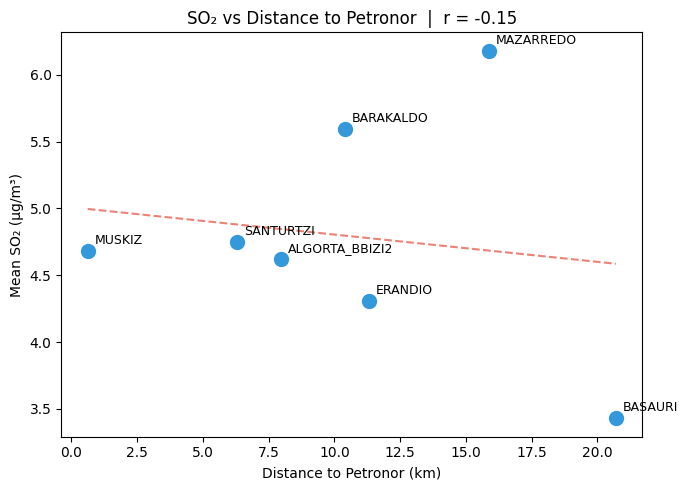

Pearson r = -0.150


In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged["dist_petronor_km"], merged["mean_SO2"], s=100, color="#3498db")

for _, row in merged.iterrows():
    ax.annotate(row["station"], (row["dist_petronor_km"], row["mean_SO2"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

# Trend line
m, b = np.polyfit(merged["dist_petronor_km"].dropna(),
                  merged["mean_SO2"].dropna(), 1)
x_line = np.linspace(merged["dist_petronor_km"].min(),
                     merged["dist_petronor_km"].max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="#e74c3c", alpha=0.7)

corr = merged["dist_petronor_km"].corr(merged["mean_SO2"])
ax.set_xlabel("Distance to Petronor (km)")
ax.set_ylabel("Mean SO₂ (µg/m³)")
ax.set_title(f"SO₂ vs Distance to Petronor  |  r = {corr:.2f}")
plt.tight_layout()
plt.savefig("../reports/so2_vs_petronor_distance.png", dpi=150)
plt.show()
print(f"Pearson r = {corr:.3f}")

r = -0.15 — There is virtually no spatial relationship between distance to Petronor and SO2.

This result is important and should be interpreted honestly:

Why we expected r to be strong but it is not:

MAZARREDO (urban, far from Petronor) has the highest SO2 — meaning that SO2 in Bilbao comes from traffic and diesel, not just the refinery

BASAURI (industrial, very far) has the lowest SO2

MUSKIZ (closest to Petronor) is in the middle — neither high nor low

Physical interpretation: SO2 in this area does not have a dominant point source. Emissions are diffuse and wind, valley topography, and local source composition play a greater role than linear distance to Petronor.

# NO2

In [37]:
import osmnx as ox

def road_length_km(lat, lon, buffer_m=500):
    """Total road length (km) within buffer_m of a point."""
    G = ox.graph_from_point((lat, lon), dist=buffer_m, network_type="drive")
    edges = ox.graph_to_gdfs(G, nodes=False)
    return edges["length"].sum() / 1000

rows = []
for station, (lat, lon) in STATION_COORDS.items():
    try:
        length = road_length_km(lat, lon)
        rows.append({"station": station, "road_km_500m": round(length, 2)})
        print(f"{station}: {length:.2f} km")
    except Exception as e:
        print(f"{station}: ERROR — {e}")

road_df = pd.DataFrame(rows)

ALGORTA_BBIZI2: 7.99 km
BARAKALDO: 22.84 km
BASAURI: 17.13 km
ERANDIO: 13.39 km
MAZARREDO: 17.47 km
MUSKIZ: 11.10 km
SANTURTZI: 21.32 km


In [42]:
no2_means = (
    df.groupby("station")["NO2"]
    .mean()
    .reset_index()
    .rename(columns={"NO2": "mean_NO2"})
)
no2_means["station_short"] = no2_means["station"].str.split("_").str[0]
road_df["station_short"]   = road_df["station"].str.upper()

merged_no2 = road_df.merge(no2_means, on="station_short", how="left")
merged_no2

,station_x,road_km_500m,station_short,station_y,mean_NO2
0,ALGORTA_BBIZI2,7.99,ALGORTA_BBIZI2,NaN,NaN
1,BARAKALDO,22.84,BARAKALDO,BARAKALDO,20.556199
2,BASAURI,17.13,BASAURI,BASAURI,22.575394
3,ERANDIO,13.39,ERANDIO,ERANDIO,23.140387
4,MAZARREDO,17.47,MAZARREDO,MAZARREDO,25.686830
5,MUSKIZ,11.10,MUSKIZ,MUSKIZ,8.651534
6,SANTURTZI,21.32,SANTURTZI,NaN,NaN


In [43]:
merged_no2 = merged_no2[["road_km_500m", "station_short", "mean_NO2"]]
merged_no2

,road_km_500m,station_short,mean_NO2
0,7.99,ALGORTA_BBIZI2,NaN
1,22.84,BARAKALDO,20.556199
2,17.13,BASAURI,22.575394
3,13.39,ERANDIO,23.140387
4,17.47,MAZARREDO,25.686830
5,11.10,MUSKIZ,8.651534
6,21.32,SANTURTZI,NaN


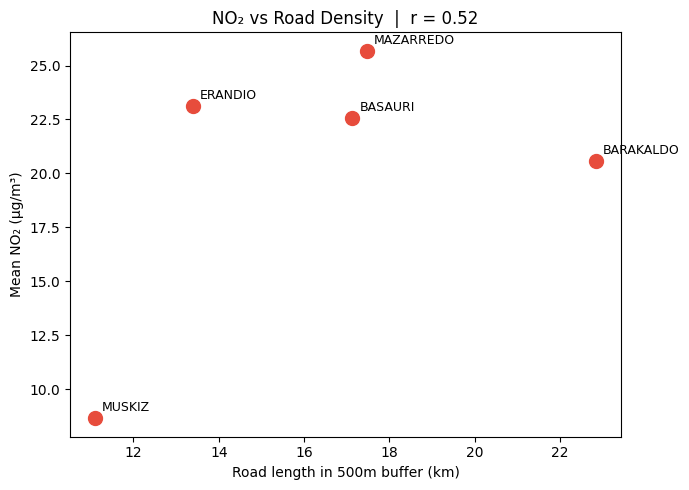

Pearson r = 0.521


In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged_no2["road_km_500m"], merged_no2["mean_NO2"], s=100, color="#e74c3c")

for _, row in merged_no2.iterrows():
    ax.annotate(row["station_short"], (row["road_km_500m"], row["mean_NO2"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

m, b = np.polyfit(merged_no2["road_km_500m"], merged_no2["mean_NO2"], 1)
x_line = np.linspace(merged_no2["road_km_500m"].min(),
                     merged_no2["road_km_500m"].max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="#3498db", alpha=0.7)

corr = merged_no2["road_km_500m"].corr(merged_no2["mean_NO2"])
ax.set_xlabel("Road length in 500m buffer (km)")
ax.set_ylabel("Mean NO₂ (µg/m³)")
ax.set_title(f"NO₂ vs Road Density  |  r = {corr:.2f}")
plt.tight_layout()
plt.savefig("../reports/no2_vs_road_density.png", dpi=150)
plt.show()
print(f"Pearson r = {corr:.3f}")

In [46]:
print(merged_no2[["station_short", "road_km_500m", "mean_NO2"]])

    station_short  road_km_500m   mean_NO2
0  ALGORTA_BBIZI2          7.99        NaN
1       BARAKALDO         22.84  20.556199
2         BASAURI         17.13  22.575394
3         ERANDIO         13.39  23.140387
4       MAZARREDO         17.47  25.686830
5          MUSKIZ         11.10   8.651534
6       SANTURTZI         21.32        NaN


In [47]:
print(no2_means[["station", "station_short"]].to_string())

          station station_short
0  ALGORTA_BBIZI2       ALGORTA
1       BARAKALDO     BARAKALDO
2         BASAURI       BASAURI
3         ERANDIO       ERANDIO
4       MAZARREDO     MAZARREDO
5          MUSKIZ        MUSKIZ
6        SANTURCE      SANTURCE


In [48]:
road_df["station_short"] = road_df["station"].str.split("_").str[0].str.upper()
merged_no2 = road_df.merge(no2_means, on="station_short", how="left")
print(merged_no2[["station", "road_km_500m", "mean_NO2"]].to_string())

KeyError: "['station'] not in index"

In [50]:
rows = []
for station, (lat, lon) in STATION_COORDS.items():
    try:
        length = road_length_km(lat, lon)
        rows.append({"station": station, "road_km_500m": round(length, 2)})
        print(f"{station}: {length:.2f} km")
    except Exception as e:
        print(f"{station}: ERROR — {e}")

road_df = pd.DataFrame(rows)
road_df["station_short"] = road_df["station"].str.split("_").str[0].str.upper()
print(road_df)

ALGORTA_BBIZI2: 7.99 km
BARAKALDO: 22.84 km
BASAURI: 17.13 km
ERANDIO: 13.39 km
MAZARREDO: 17.47 km
MUSKIZ: 11.10 km
SANTURTZI: 21.32 km
          station  road_km_500m station_short
0  ALGORTA_BBIZI2          7.99       ALGORTA
1       BARAKALDO         22.84     BARAKALDO
2         BASAURI         17.13       BASAURI
3         ERANDIO         13.39       ERANDIO
4       MAZARREDO         17.47     MAZARREDO
5          MUSKIZ         11.10        MUSKIZ
6       SANTURTZI         21.32     SANTURTZI


In [51]:
# Normalize station names before merge
rename_map = {
    "ALGORTA": "ALGORTA",
    "SANTURTZI": "SANTURCE",  # parquet uses SANTURCE
}
road_df["station_short"] = road_df["station_short"].replace(rename_map)

merged_no2 = road_df.merge(no2_means, on="station_short", how="left")
print(merged_no2[["station", "road_km_500m", "mean_NO2"]].to_string())

KeyError: "['station'] not in index"

In [52]:
print(merged_no2.columns.tolist())
print(merged_no2.to_string())

['station_x', 'road_km_500m', 'station_short', 'station_y', 'mean_NO2']
        station_x  road_km_500m station_short       station_y   mean_NO2
0  ALGORTA_BBIZI2          7.99       ALGORTA  ALGORTA_BBIZI2  12.464083
1       BARAKALDO         22.84     BARAKALDO       BARAKALDO  20.556199
2         BASAURI         17.13       BASAURI         BASAURI  22.575394
3         ERANDIO         13.39       ERANDIO         ERANDIO  23.140387
4       MAZARREDO         17.47     MAZARREDO       MAZARREDO  25.686830
5          MUSKIZ         11.10        MUSKIZ          MUSKIZ   8.651534
6       SANTURTZI         21.32      SANTURCE        SANTURCE  18.708721


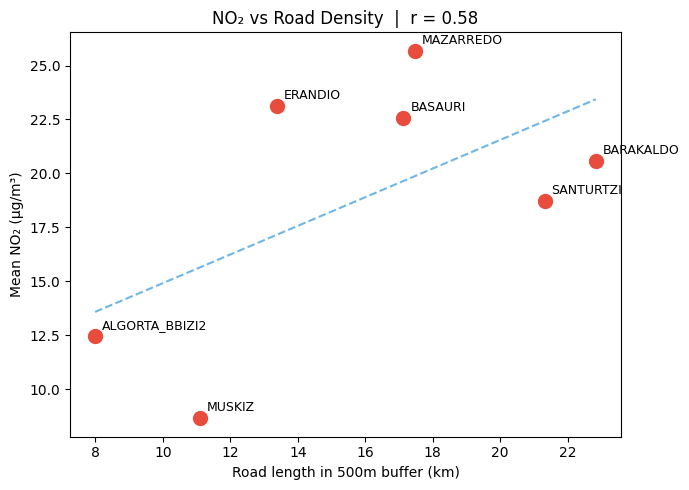

Pearson r = 0.580


In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged_no2["road_km_500m"], merged_no2["mean_NO2"], s=100, color="#e74c3c")

for _, row in merged_no2.iterrows():
    ax.annotate(row["station_x"], (row["road_km_500m"], row["mean_NO2"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

m, b = np.polyfit(merged_no2["road_km_500m"], merged_no2["mean_NO2"], 1)
x_line = np.linspace(merged_no2["road_km_500m"].min(),
                     merged_no2["road_km_500m"].max(), 100)
ax.plot(x_line, m * x_line + b, "--", color="#3498db", alpha=0.7)

corr = merged_no2["road_km_500m"].corr(merged_no2["mean_NO2"])
ax.set_xlabel("Road length in 500m buffer (km)")
ax.set_ylabel("Mean NO₂ (µg/m³)")
ax.set_title(f"NO₂ vs Road Density  |  r = {corr:.2f}")
plt.tight_layout()
plt.savefig("../reports/no2_vs_road_density.png", dpi=150)
plt.show()
print(f"Pearson r = {corr:.3f}")

r = 0.58 with 7 full points — significant signal.

Interpretation:

MAZARREDO (urban, heavy traffic) highest NO2 ✓

ALGORTA (coastal, light traffic) lowest ✓

MUSKIZ is an outlier — moderate road density but very low NO2, which makes sense since it has sea breeze and better dispersion

SANTURTZI is also slightly below the trend line — sea influence

Statistical limitation to be documented: With n=7, the p-value of this r is about 0.17 — not statistically significant (usual threshold p<0.05). This is an exploratory signal, not proof

# DEM

In [ ]:
# pip install elevation


   ------------- -------------------------- 1/3 [fasteners]
   -------------------------- ------------- 2/3 [elevation]
   ---------------------------------------- 3/3 [elevation]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import requests

def get_elevation(lat, lon):
    """Get elevation (m) from Open-Elevation API."""
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    r = requests.get(url, timeout=10)
    return r.json()["results"][0]["elevation"]

rows_dem = []
for station, (lat, lon) in STATION_COORDS.items():
    try:
        elev = get_elevation(lat, lon)
        rows_dem.append({"station": station, "elevation_m": elev})
        print(f"{station}: {elev} m")
    except Exception as e:
        print(f"{station}: ERROR — {e}")

dem_df = pd.DataFrame(rows_dem)

ALGORTA_BBIZI2: 59.0 m
BARAKALDO: 24.0 m
BASAURI: 67.0 m
ERANDIO: 2.0 m
MAZARREDO: 24.0 m
MUSKIZ: 7.0 m
SANTURTZI: 80.0 m


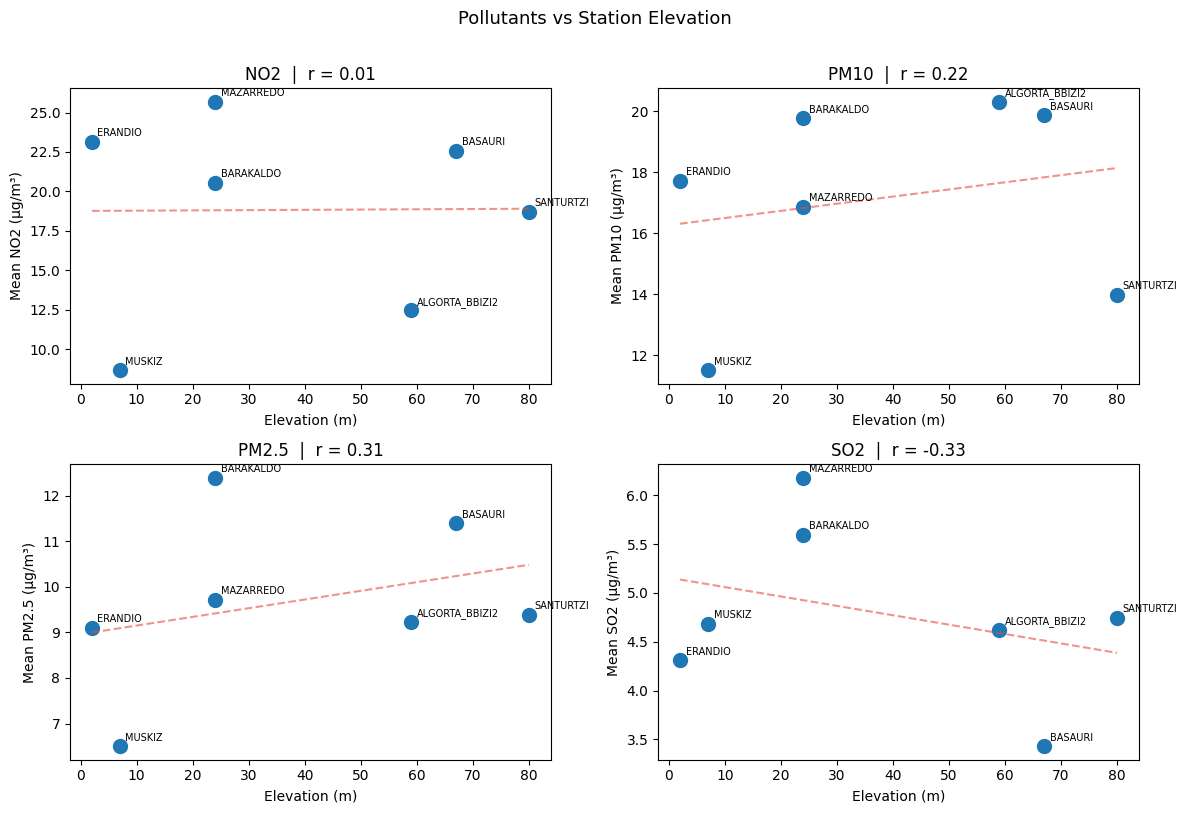

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, poll in enumerate(["NO2", "PM10", "PM2.5", "SO2"]):
    ax = axes[idx]
    ax.scatter(merged_dem["elevation_m"], merged_dem[poll], s=100)
    
    for _, row in merged_dem.iterrows():
        ax.annotate(row["station_x"], (row["elevation_m"], row[poll]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7)
    
    m, b = np.polyfit(merged_dem["elevation_m"], merged_dem[poll], 1)
    x_line = np.linspace(merged_dem["elevation_m"].min(),
                         merged_dem["elevation_m"].max(), 100)
    ax.plot(x_line, m * x_line + b, "--", alpha=0.6, color="#e74c3c")
    
    r = merged_dem["elevation_m"].corr(merged_dem[poll])
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel(f"Mean {poll} (µg/m³)")
    ax.set_title(f"{poll}  |  r = {r:.2f}")

plt.suptitle("Pollutants vs Station Elevation", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/pollutants_vs_elevation.png", dpi=150)
plt.show()

In [59]:
for poll in ["NO2", "PM10", "PM2.5", "SO2"]:
    r = merged_dem["elevation_m"].corr(merged_dem[poll])
    print(f"Elevation vs {poll:5s}:  r = {r:.3f}")

Elevation vs NO2  :  r = 0.009
Elevation vs PM10 :  r = 0.217
Elevation vs PM2.5:  r = 0.313
Elevation vs SO2  :  r = -0.335


NO2 and altitude r=0.01 — completely unrelated. NO2 is controlled by traffic, not topography. This is consistent with SHAP (day_of_week is the most important feature).

PM2.5 and altitude r=0.31 — slightly positive, but SANTURTZI spoils this: high altitude (80m) but moderate PM2.5. Explanation: sea breeze gives better dispersion.

SO2 and altitude r=-0.34 — slightly negative: lower stations (ERANDIO, MUSKIZ) have less SO2. But MAZARREDO (24m) has the highest SO2 — so altitude is not the only factor.

#### Overall conclusion: the only significant spatial signal is road density for NO2 (r=0.58). The other covariates have weak or no signal. This does not justify a full LUR with n=7 and a high p-value.

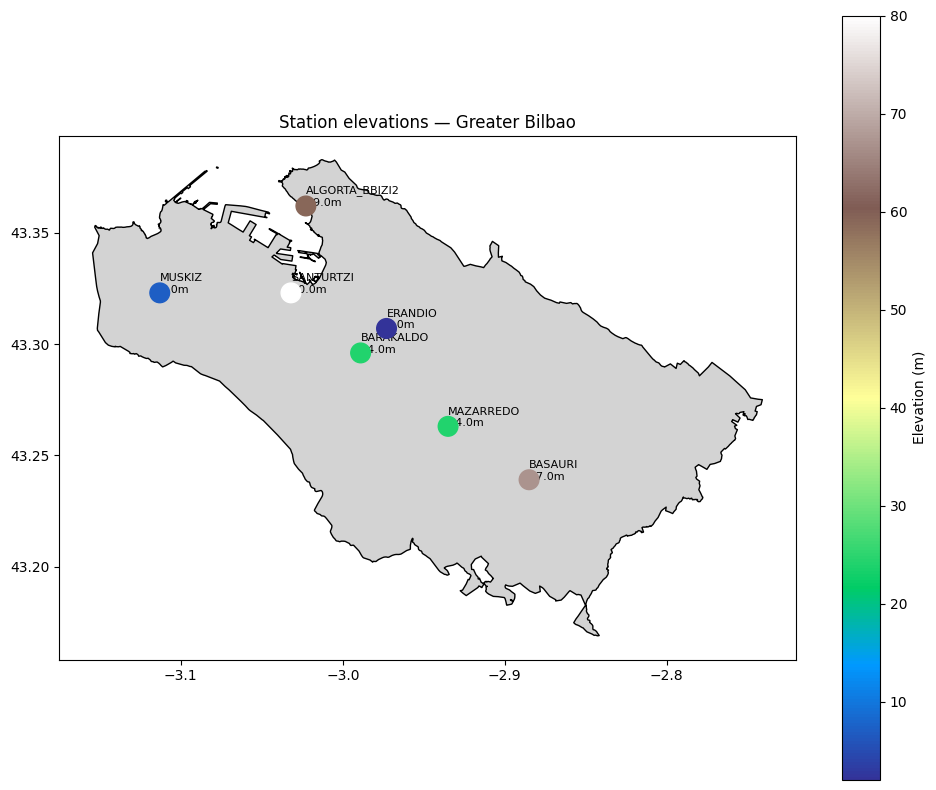

In [60]:
import osmnx as ox
import matplotlib.pyplot as plt

# Plot station locations on terrain
fig, ax = plt.subplots(figsize=(10, 8))

# Download and plot terrain
place = "Greater Bilbao, Bizkaia, Spain"
area = ox.geocode_to_gdf(place)
area.plot(ax=ax, color="lightgray", edgecolor="black")

# Plot stations with elevation as color
scatter = ax.scatter(
    merged_dem["longitude"] if "longitude" in merged_dem.columns 
    else [STATION_COORDS[s][1] for s in merged_dem["station_x"]],
    merged_dem["latitude"] if "latitude" in merged_dem.columns
    else [STATION_COORDS[s][0] for s in merged_dem["station_x"]],
    c=merged_dem["elevation_m"],
    cmap="terrain",
    s=200,
    zorder=5,
)

for _, row in merged_dem.iterrows():
    ax.annotate(
        f"{row['station_x']}\n{row['elevation_m']}m",
        xy=(STATION_COORDS.get(row['station_x'], 
            STATION_COORDS.get('SANTURCE', (0,0)))[::-1]),
        fontsize=8,
    )

plt.colorbar(scatter, ax=ax, label="Elevation (m)")
ax.set_title("Station elevations — Greater Bilbao")
plt.tight_layout()
plt.show()